# Purpose: make a space for discriminating learners from non, controls and mutants

In [2]:
from scipy.io import loadmat
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
from mapd import Trial, Table, Sinq 
from mapd.sinq_builders import build_composite_sinq, subset_sinq
import h5py
import glob
import numpy as np
import pickle
import plotly.express as px
import matplotlib.colors as mcolors
# import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.figure import Figure
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)  # reset to defaults
mpl.rcParams['pdf.fonttype'] = 42         # embed fonts as text, not paths
mpl.rcParams['svg.fonttype'] = 'none'     # keep text editable in SVG
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['font.size'] = 11

import seaborn as sns

import random

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

%load_ext autoreload
%autoreload 2


%matplotlib widget

def refresh_table_addons():
    import importlib
    import mapd.table_plotters as tps
    import mapd.table_scalars as tbs
    importlib.reload(tps)
    importlib.reload(tbs)

    for name in dir(tps):
        if name.startswith('_'):
            continue
        attr = getattr(tps, name)
        setattr(Table, name[len("plot_"):], attr)
    
    for name in dir(tbs):
        if name.startswith('_'):
            continue
        if name.startswith('compute_'):
            attr = getattr(tbs, name)
            setattr(Table, name[len("compute_"):], attr)


# Fig dir for PCA analysis
pca_fig_dir = 'Figure3_6_PCA_LDA'
control_dir = f'{pca_fig_dir}/controls'
mutants_dir = f'{pca_fig_dir}/mutants'

control_export_dir = f"{control_dir}/exports"
mutants_export_dir = f"{mutants_dir}/exports"

factor_plots_dir = f'{pca_fig_dir}/factor_plots'

os.makedirs(pca_fig_dir, exist_ok=True)
os.makedirs(control_dir, exist_ok=True)
os.makedirs(mutants_dir, exist_ok=True)
os.makedirs(control_export_dir, exist_ok=True)
os.makedirs(mutants_export_dir, exist_ok=True)
os.makedirs(f'{control_dir}/expts_in_LDA_space', exist_ok=True)
os.makedirs(factor_plots_dir, exist_ok=True)

# def mk_dir(id):
#     folder_path = f'./{fig_dir}/{id}'
#     os.makedirs(folder_path, exist_ok=True)
#     export_path = f'{folder_path}/exports'
#     os.makedirs(export_path, exist_ok=True)

# control_dir


# Load learners vs. control sinq

In [3]:
sinq_0 = Sinq(sinqname='dataset_1')
sinq_1 = Sinq(sinqname='dataset_2_controls')
sinq = build_composite_sinq(name='dataset_1_2_pca_lda',sources=[sinq_0,sinq_1])

Found data directory: D:\Data
Found data directory: D:\Data
Found data directory: D:\Data
File D:\Data\Sinqs\dataset_1_2_pca_lda.pkl exists but starting fresh.


In [4]:
op_df = sinq.display_df(show_tags=True)
op_df['learn'] = sinq.has_tag('learn')
op_df['control'] = sinq.has_tag('control')
op_df[['genotype','tags','learn','control']]

,genotype,tags,learn,control
210302_F1_C2,Hot-Cell-Gal4 (test),"Figure1, learn",True,False
210331_F2_C1,Hot-Cell-LexA_Chr;81A06_pJFRC7,"Figure1, no_learn",False,False
210405_F1_C1,Hot-Cell-LexA_Chr;81A06_pJFRC7,"Figure1, learn",True,False
210604_F1_C1,Hot-Cell-LexA_Chr;35c09_pJFRC7,"Figure1, learn",True,False
210903_F3_C1,Hot-Cell-LexA_Chr;35C09_pJFRC7,"Figure1, learn",True,False
...,...,...,...,...
260619_F1_C1,+;SS61350_pJFRC7,"control, extension",False,True
260619_F2_C1,+;SS61350_pJFRC7,"control, extension",False,True
260623_F1_C1,+;pJFRC7_+;81A06-Gal4_+,"control, extension",False,True
260623_F2_C1,+;pJFRC7_+;81A06-Gal4_+,"control, extension",False,True


# Compare learners vs. not

In [5]:
# print([i for i in op_df['genotype'].unique()])
list(op_df['genotype'].unique())

['Hot-Cell-Gal4 (test)',
 'Hot-Cell-LexA_Chr;81A06_pJFRC7',
 'Hot-Cell-LexA_Chr;35c09_pJFRC7',
 'Hot-Cell-LexA_Chr;35C09_pJFRC7',
 'Hot-Cell-LexA_Chr;78E05_pJFRC7',
 'Hot-Cell-LexA_Chr;31H05_pJFRC7',
 'SS61350_pJFRC7',
 '+;31H05-Gal4_pJFRC7',
 '+;TH-Gal4_UAS-Kir2_1',
 '+;pJFRC7;31H05-Gal4',
 '+;pJFRC7;SS61350',
 '+;SS61350_pJFRC7',
 'ppk-Gal4;10XUAS-ChR in WT',
 '+;ppk-GAL4;10XUAS-ChR',
 'Hot-Cell-Gal4_ChrinWT',
 'w, NorpA',
 '+;pJFRC7;+',
 'norpA;cry',
 '+;pJFRC7;35C09-GAL4',
 'ss61350_pJFRC7',
 'norpAE55',
 '+;pFJRC7;+',
 'norpA',
 '+;pJFRC7;81A06-GAL4',
 'NorpA e55, no arista',
 '+;pJFRC7_+;81A06-Gal4_+']

In [6]:
geno_map = {'Hot-Cell-Gal4 (test)':             'HC',
 'Hot-Cell-LexA_Chr;81A06_pJFRC7': 'HC',
 'Hot-Cell-LexA_Chr;35c09_pJFRC7': 'HC',
 'Hot-Cell-LexA_Chr;35C09_pJFRC7': 'HC',
 'Hot-Cell-LexA_Chr;78E05_pJFRC7': 'HC',
 'Hot-Cell-LexA_Chr;31H05_pJFRC7': 'HC',
 'SS61350_pJFRC7':                  '+',
 '+;31H05-Gal4_pJFRC7':             '+',
 '+;TH-Gal4_UAS-Kir2_1':            '+;TH-Gal4_UAS-Kir2_1',
 '+;pJFRC7;31H05-Gal4':             '+',
 '+;pJFRC7;SS61350':                '+',
 'ppk-Gal4;10XUAS-ChR in WT':       '+;ppk-GAL4;10XUAS-ChR',
 '+;ppk-GAL4;10XUAS-ChR':           '+;ppk-GAL4;10XUAS-ChR',
 'Hot-Cell-Gal4_ChrinWT':           'HC',
 'w, NorpA':                        'NorpA',
 '+;pJFRC7;+':                      '+',
 'norpA;cry':                       '+',
 '+;pJFRC7;35C09-GAL4':             '+',
 'ss61350_pJFRC7':                  '+',
 '+;SS61350_pJFRC7':                '+',
 'norpAE55':                        'NorpA',
 '+;pFJRC7;+':                      '+',
 'norpA':                           'NorpA',
 'NorpA e55, no arista':            'NorpA',
 '+;pJFRC7;81A06-GAL4':             '+',
 '+;pJFRC7_+;81A06-Gal4_+':         '+',
}

op_df['geno_smpl'] = op_df['genotype'].map(geno_map)
op_df.loc[op_df['geno_smpl'].isna()]

,Table,parquet,genotype,notes,note_text,tags,duration,rms_velocity,outcome_fractions_no_as_no_mv,outcome_fractions_as_off,...,most_common_fiberLED,lo_target_off_state,hi_target_off_state,probe_positive_effort,successes,hard_successes,holding_cost,learn,control,geno_smpl


## Additional factors

In [7]:
op_df.loc[op_df['learn'], 'learn_class'] = 0  # Control
op_df.loc[op_df['control'], 'learn_class'] = 1  # Control
op_df.loc[(op_df['control'] == op_df['learn']), 'learn_class'] = 2  # borderline cases

In [8]:
op_df['success_rate'] =         op_df['successes'] / op_df['num_trials']
op_df['hard_success_rate'] =    op_df['hard_successes'] / op_df['num_trials']

op_df['as_off_over_successes'] =        np.log10(op_df['outcome_fractions_as_off'] * op_df['num_trials'] + 1) / (op_df['successes'] + 1)
op_df['as_off_over_hard_successes'] =   np.log10(op_df['outcome_fractions_as_off'] * op_df['num_trials'] + 1) / (op_df['hard_successes'] + 1)

op_df['rms_velocity_bar'] = op_df['rms_velocity'] / op_df['duration']
op_df['holding_cost_bar'] = op_df['holding_cost'] / op_df['duration']
op_df['probe_positive_effort_bar'] = op_df['probe_positive_effort'] / op_df['duration']

## Leave out the extension flies for now

In [9]:
op_df_0 = op_df.copy()

In [10]:
op_df = op_df.loc[~sinq.has_tag('extension')].copy()

In [11]:
op_df

,Table,parquet,genotype,notes,note_text,tags,duration,rms_velocity,outcome_fractions_no_as_no_mv,outcome_fractions_as_off,...,control,geno_smpl,learn_class,success_rate,hard_success_rate,as_off_over_successes,as_off_over_hard_successes,rms_velocity_bar,holding_cost_bar,probe_positive_effort_bar
210302_F1_C2,None,LEDFlashWithPiezoCueControl_210302_F1_C2_Table...,Hot-Cell-Gal4 (test),"{'text': 'na ', 'tags': ['Figure1', 'learn'],...",na\n\n,"Figure1, learn",6836.72718,3.298297e+04,0.561250,0.173750,...,False,HC,0.0,0.097500,0.046250,0.027166,0.056477,4.824380,1337.972048,127.024137
210331_F2_C1,None,LEDFlashWithPiezoCueControl_210331_F2_C1_Table...,Hot-Cell-LexA_Chr;81A06_pJFRC7,"{'text': 'Seems like it should be learning', '...",Seems like it should be learning,"Figure1, no_learn",8428.02290,1.424916e+05,0.337240,0.188802,...,False,HC,2.0,0.050781,0.016927,0.054109,0.154597,16.906880,1092.177348,435.800398
210405_F1_C1,None,LEDFlashWithPiezoCueControl_210405_F1_C1_Table...,Hot-Cell-LexA_Chr;81A06_pJFRC7,"{'text': 'Long timeout, many timeouts', 'tags'...","Long timeout, many timeouts","Figure1, learn",6582.81488,3.400665e+04,0.462382,0.087774,...,False,HC,0.0,0.053292,0.020376,0.050168,0.125420,5.165975,1985.551674,205.001294
210604_F1_C1,None,LEDFlashWithPiezoCueControl_210604_F1_C1_Table...,Hot-Cell-LexA_Chr;35c09_pJFRC7,"{'text': 'Long timeout, super learner', 'tags'...","Long timeout, super learner","Figure1, learn",3685.79266,4.441894e+04,0.565714,0.102857,...,False,HC,0.0,0.042857,0.025714,0.098013,0.156820,12.051393,1768.778529,468.866721
210903_F3_C1,None,LEDFlashTriggerPiezoControl_210903_F3_C1_Table...,Hot-Cell-LexA_Chr;35C09_pJFRC7,"{'text': 'Long timeouts, ignores red, missing ...","Long timeouts, ignores red, missing later blocks","Figure1, learn",6303.51030,4.559602e+04,0.426667,0.131667,...,False,HC,0.0,0.061667,0.023333,0.050081,0.126873,7.233434,2163.267329,301.172204
210915_F1_C1,None,LEDFlashTriggerPiezoControl_210915_F1_C1_Table...,Hot-Cell-LexA_Chr;78E05_pJFRC7,"{'text': 'na', 'tags': ['Figure1', 'learn'], '...",na,"Figure1, learn",5857.48988,4.565943e+04,0.410463,0.084507,...,False,HC,0.0,0.054326,0.024145,0.058338,0.125651,7.795051,2263.552170,397.411656
210917_F2_C1,None,LEDFlashTriggerPiezoControl_210917_F2_C1_Table...,Hot-Cell-LexA_Chr;31H05_pJFRC7,"{'text': 'na', 'tags': ['Figure1', 'learn'], '...",na,"Figure1, learn",5780.00094,7.468363e+04,0.315498,0.276753,...,False,HC,0.0,0.092251,0.035055,0.042725,0.108949,12.921041,2090.349676,737.470068
250226_F2_C1,None,LEDFlashTriggerPiezoControl_250226_F2_C1_Table...,SS61350_pJFRC7,"{'text': 'Never got it, tried hard', 'tags': [...","Never got it, tried hard","Figure1, no_learn",9447.21096,5.064863e+05,0.261153,0.455930,...,False,+,2.0,0.101197,0.031556,0.027907,0.087442,53.612255,3100.072196,2681.910405
250227_F2_C1,None,LEDFlashTriggerPiezoControl_250227_F2_C1_Table...,SS61350_pJFRC7,"{'text': 'na', 'tags': ['Figure1', 'learn'], '...",na,"Figure1, learn",7224.62008,2.367302e+05,0.478431,0.315033,...,False,+,0.0,0.057516,0.037908,0.052974,0.079461,32.767155,1777.278639,1073.811876
250227_F3_C1,None,LEDFlashTriggerPiezoControl_250227_F3_C1_Table...,SS61350_pJFRC7,"{'text': 'na', 'tags': ['Figure1', 'learn'], '...",na,"Figure1, learn",6078.90756,3.924676e+05,0.360502,0.333856,...,False,+,0.0,0.042320,0.018809,0.083229,0.179263,64.562195,1652.064731,2822.434010


# PCA on all factors

In [12]:

# import matplotlib.pyplot as plt

# folder_path = "./Figure2/exports"
# figure_path = "./Figure2/"

# labels = ['learn_class','learn','note_text','geno_smpl']

# factors = [
#     'outcome_fractions_no_as_no_mv',
#     'outcome_fractions_no_as_mv',  
#     'outcome_fractions_as_off',
#     'outcome_fractions_as_off_late',
#     'outcome_fractions_timeout',
#     'hi_lo_shift',
#     'lo_state_on_target',
#     'hi_state_on_target',
#     'lo_target_off_state',
#     'hi_target_off_state',
#     'success_rate',
#     'hard_success_rate',
#     'as_off_over_successes',
#     'as_off_over_hard_successes',
#     'rms_velocity_bar',
#     'holding_cost_bar',
#     'probe_positive_effort_bar',
# ]
# pca_df = op_df.loc[:,labels+factors]

# # y = op_df['learners']
# X = pca_df.drop(columns=labels)

# scaler = StandardScaler()
# x_scaled = scaler.fit_transform(X,)

# pca = PCA(n_components=10,
#           copy=True, 
#           whiten=False, 
#           svd_solver='full', 
#           tol=0.0, 
#           iterated_power='auto')
# X_pca = pca.fit_transform(x_scaled)


# # Variance ratios
# vr = pca.explained_variance_ratio_
# cum = np.cumsum(vr)

# # How much variance in top 3?
# print(f"Top 4 PCs capture: {cum[3]:.2%} of variance")

# # Make a projection DataFrame
# proj_df = pd.DataFrame(
#     X_pca,
#     columns=[f"PC{i+1}" for i in range(pca.n_components_)],
#     index=pca_df.index
# )

# proj_df[labels] = pca_df[labels]
# col_str = 'learn_class'

# cats = pd.Index(sorted(proj_df[col_str].unique()))
# n = len(cats)
# palette = sns.color_palette("tab10", n)
# color_map = dict(zip(cats, palette))

# # Reuse proj_df and color_map from above
# plot_df = proj_df.reset_index().rename(columns={"index":"fly_id"})

# # Convert seaborn/matplotlib colors to hex for plotly
# color_map = dict(zip(cats, palette))
# color_map_hex = {g: mcolors.to_hex(c) for g, c in color_map.items()}

# fig = px.scatter_3d(
#     plot_df,
#     x="PC1", y="PC2", z="PC3",
#     color=col_str,
#     color_discrete_map=color_map_hex,
#     hover_data=["fly_id", "geno_smpl",'note_text'],
#     title="PCA Projections (PC1–PC3)"
# )
# fig.update_traces(marker=dict(size=5, opacity=0.9))
# fig.update_layout(
#     legend_title_text="Genotype",
#     scene=dict(
#         xaxis_title=f"PC1 ({pca.explained_variance_ratio_[0]:.1%})",
#         yaxis_title=f"PC2 ({pca.explained_variance_ratio_[1]:.1%})",
#         zaxis_title=f"PC3 ({pca.explained_variance_ratio_[2]:.1%})",
#     )
# )

# fig.update_layout(
#     width=1100, height=850,                    # << size here
#     margin=dict(l=60, r=260, t=70, b=50),      # leave space for a tall legend
#     font=dict(size=16),
#     legend=dict(y=1, x=1.02, yanchor="top"),   # legend outside
#     scene=dict(
#         xaxis_title=f"PC1 ({pca.explained_variance_ratio_[0]:.1%})",
#         yaxis_title=f"PC2 ({pca.explained_variance_ratio_[1]:.1%})",
#         zaxis_title=f"PC3 ({pca.explained_variance_ratio_[2]:.1%})",
#         xaxis=dict(tickfont=dict(size=12)),
#         yaxis=dict(tickfont=dict(size=12)),
#         zaxis=dict(tickfont=dict(size=12)),
#     ),
#     hoverlabel=dict(font_size=14)
# )

# fig.show()
# for leg in [False,True]:
#     for col in ['learn','geno_smpl']:
#         cats = pd.Index(sorted(proj_df[col].unique()))
#         n = len(cats)
#         palette = sns.color_palette("tab20", n) if n <= 20 else sns.husl_palette(n)
#         color_map = dict(zip(cats, palette))
#         point_colors = [mcolors.to_hex(color_map[g]) for g in proj_df[col]]

#         # --- Helper to save a 2D scatter as SVG ---
#         def save_pc2d(proj, pca_obj, xpc="PC1", ypc="PC2", fname="plot.svg"):
#             fig, ax = plt.subplots(figsize=(7.5, 6))
#             ax.scatter(proj[xpc], proj[ypc], s=50, alpha=0.9, c=point_colors)

#             # Axis labels with variance explained
#             pc_names = ["PC1","PC2","PC3"]
#             exp = {pc_names[i]: pca_obj.explained_variance_ratio_[i] for i in range(3)}
#             ax.set_xlabel(f"{xpc} ({exp[xpc]:.1%} var)")
#             ax.set_ylabel(f"{ypc} ({exp[ypc]:.1%} var)")
#             ax.set_title(f"PCA: {ypc} vs {xpc}")

#             # Legend (handles many genotypes)
#             handles = [plt.Line2D([0],[0], marker='o', linestyle='', markersize=7,
#                                 markerfacecolor=mcolors.to_hex(color_map[g])) for g in cats]
#             ncol = 1 if n < 12 else 2 if n <= 24 else 3
#             if leg:
#                 ax.legend(handles, list(cats), title=col,
#                         bbox_to_anchor=(1.02, 1), loc="upper left", ncol=ncol, fontsize=8)

#             ax.grid(True, alpha=0.2)
#             plt.tight_layout()
#             fig.savefig(fname, format="svg", dpi=300, bbox_inches="tight")
#             plt.close(fig)
#             print(f"Saved {fname}")

#         # --- Make the two figures ---
#         save_pc2d(proj_df, pca, xpc="PC1", ypc="PC2", fname=f"./Figure2/pca_PC2_vs_PC1_{col}_legend_{leg}.svg")
#         save_pc2d(proj_df, pca, xpc="PC1", ypc="PC3", fname=f"./Figure2/pca_PC3_vs_PC1_{col}_legend_{leg}.svg")

# loadings = pd.DataFrame(
#     pca.components_,
#     index=[f"PC{i+1}" for i in range(pca.n_components_)],
#     columns=X.columns
# )

# # Optional: variance-scaled loadings (correlations) sometimes used for “importance”:
# # These are eigenvectors scaled by sqrt(eigenvalues)
# var_scaled_loadings = pd.DataFrame(
#     (pca.components_.T * np.sqrt(pca.explained_variance_)).T,
#     index=[f"PC{i+1}" for i in range(pca.n_components_)],
#     columns=X.columns
# )

# # --- 4) Plot PC1 loadings sorted by absolute magnitude ---
# for pc in ["PC1",'PC2','PC3']:
#     pc_l = loadings.loc[pc].sort_values(key=np.abs, ascending=False)

#     fig = plt.figure(figsize=(10, 5))
#     pc_l.plot(kind="bar")
#     plt.title(f"{pc} Loadings (feature weights)")
#     plt.ylabel("Loading")
#     plt.xlabel("Features (sorted by |loading|)")
#     plt.tight_layout()

#     # If you want the top-N features programmatically:
#     topN = 15
#     # pc1_top = pc_l.head(topN)
#     # print(pc1_top)
#     fig.savefig(f'./Figure2/{pc}.svg')

# PCA on a subset of factors

In [13]:
labels = ['geno_smpl','learn_class','learn','control','note_text']

factors = [
    'outcome_fractions_no_as_no_mv',        # pc1, 3
    #'outcome_fractions_no_as_mv',          # pc3, 2
    'outcome_fractions_as_off',            # pc2, 1
    #'outcome_fractions_as_off_late',
    #'outcome_fractions_timeout',           # pc2, 4
    #'hi_lo_shift',
    'lo_state_on_target',                   # pc1, 2
    'hi_state_on_target',                   # pc1, 1
    'lo_target_off_state',                  # pc3, 1
    'hi_target_off_state',                  # pc3, 4
    'success_rate',                         # pc2, 5
    'hard_success_rate',                    # pc1, 4
    'as_off_over_successes',                # pc3, 4
    'as_off_over_hard_successes',           # pc1, 5
    'rms_velocity_bar',                     # pc2, 3
    #'holding_cost_bar',
    'probe_positive_effort_bar',            # pc2, 2, pc3, 5
]
pca_df = op_df.loc[:,labels+factors]

# y = op_df['learners']
X = pca_df.drop(columns=labels)

scaler = StandardScaler()
x_scaled = scaler.fit_transform(X,)

pca = PCA(n_components=10,
          copy=True, 
          whiten=False, 
          svd_solver='full', 
          tol=0.0, 
          iterated_power='auto')
X_pca = pca.fit_transform(x_scaled)


# Variance ratios
vr = pca.explained_variance_ratio_
cum = np.cumsum(vr)

# How much variance in top 3?
print(f"Top 4 PCs capture: {cum[6]:.2%} of variance")

# Make a projection DataFrame
proj_df = pd.DataFrame(
    X_pca,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=pca_df.index
)

proj_df[labels] = pca_df[labels]

Top 4 PCs capture: 93.51% of variance


In [14]:
cum

array([0.39783341, 0.56674613, 0.68572739, 0.76797952, 0.83570551,
       0.89136125, 0.93511717, 0.96802631, 0.98561932, 0.9934882 ])

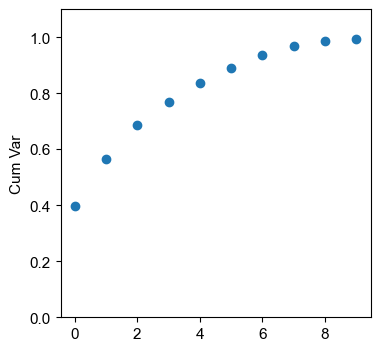

In [15]:
from IPython.display import display

fig = Figure(figsize=(4,4))
# plt.figure(figsize=(5,5))
ax = fig.add_subplot(1, 1, 1)
ax.scatter([i for i in range(pca.n_components_)],cum)
ax.set_ylim([0, 1.1])
ax.set_ylabel('Cum Var')
display(fig)

fig.savefig(f'{control_dir}/variance_by_PC.svg')

In [16]:
import plotly.io as pio
from IPython.display import display


col_str = 'learn'

cats = pd.Index(sorted(proj_df[col_str].unique()))
n = len(cats)
palette = sns.color_palette("tab10", n)
color_map = dict(zip(cats, palette))

# Reuse proj_df and color_map from above
plot_df = proj_df.reset_index().rename(columns={"index":"fly_id"})

# Convert seaborn/matplotlib colors to hex for plotly
color_map = dict(zip(cats, palette))
color_map_hex = {g: mcolors.to_hex(c) for g, c in color_map.items()}

fig = px.scatter_3d(
    plot_df,
    x="PC1", y="PC2", z="PC3",
    color=col_str,
    color_discrete_map=color_map_hex,
    hover_data=["fly_id", "geno_smpl",'note_text'],
    title="PCA Projections (PC1–PC3)"
)
fig.update_traces(marker=dict(size=5, opacity=0.9))
fig.update_layout(
    legend_title_text=col_str,
    scene=dict(
        xaxis_title=f"PC1 ({pca.explained_variance_ratio_[0]:.1%})",
        yaxis_title=f"PC2 ({pca.explained_variance_ratio_[1]:.1%})",
        zaxis_title=f"PC3 ({pca.explained_variance_ratio_[2]:.1%})",
    )
)

fig.update_layout(
    width=1100, height=850,                    # << size here
    margin=dict(l=60, r=260, t=70, b=50),      # leave space for a tall legend
    font=dict(family="Arial",size=16),
    legend=dict(y=1, x=1.02, yanchor="top"),   # legend outside
    scene=dict(
        xaxis_title=f"PC1 ({pca.explained_variance_ratio_[0]:.1%})",
        yaxis_title=f"PC2 ({pca.explained_variance_ratio_[1]:.1%})",
        zaxis_title=f"PC3 ({pca.explained_variance_ratio_[2]:.1%})",
        xaxis=dict(tickfont=dict(size=12)),
        yaxis=dict(tickfont=dict(size=12)),
        zaxis=dict(tickfont=dict(size=12)),
    ),
    hoverlabel=dict(font_size=14)
)


fig.update_layout(
    scene_camera=dict(
        eye=dict(x=-1.6, y=-2.1, z=1),   # rotate around X/Y/Z
        up=dict(x=0, y=0, z=1.5)       # z-axis is vertical
    )
)

# fig = go.FigureWidget(fig)

# show the fig and attach listener
display(fig)

# Attach a listener that prints the camera dict when you rotate
from IPython.display import Javascript

display(Javascript("""
require(["base/js/namespace"], function(Jupyter) {
  Jupyter.notebook.kernel.execute("last_camera = None")  // initialize
  const figs = document.querySelectorAll('.js-plotly-plot');
  figs.forEach(fig => {
    fig.on('plotly_relayout', ev => {
      if(ev['scene.camera']){
        const cam = JSON.stringify(ev['scene.camera']);
        Jupyter.notebook.kernel.execute("last_camera = " + cam);
        console.log("Camera updated:", ev['scene.camera']);
      }
    });
  });
});
"""))

# fig.show()
# fig.write_image(f'./Figure3/pca_proj_3d.png)
# fig.write_image("pca_projection.png", width=4400, height=3400, scale=1)

<IPython.core.display.Javascript object>

In [17]:
# for leg in [False,True]:
#     for col in ['learn','geno_smpl']:
#         cats = pd.Index(sorted(proj_df[col].unique()))
#         n = len(cats)
#         palette = sns.color_palette("tab20", n) if n <= 20 else sns.husl_palette(n)
#         color_map = dict(zip(cats, palette))
#         point_colors = [mcolors.to_hex(color_map[g]) for g in proj_df[col]]

#         # --- Helper to save a 2D scatter as SVG ---
#         def save_pc2d(proj, pca_obj, xpc="PC1", ypc="PC2", fname="plot.svg"):
#             fig, ax = plt.subplots(figsize=(7.5, 6))
#             ax.scatter(proj[xpc], proj[ypc], s=50, alpha=0.9, c=point_colors)

#             # Axis labels with variance explained
#             pc_names = ["PC1","PC2","PC3"]
#             exp = {pc_names[i]: pca_obj.explained_variance_ratio_[i] for i in range(3)}
#             ax.set_xlabel(f"{xpc} ({exp[xpc]:.1%} var)")
#             ax.set_ylabel(f"{ypc} ({exp[ypc]:.1%} var)")
#             ax.set_title(f"PCA: {ypc} vs {xpc}")

#             # Legend (handles many genotypes)
#             handles = [plt.Line2D([0],[0], marker='o', linestyle='', markersize=7,
#                                 markerfacecolor=mcolors.to_hex(color_map[g])) for g in cats]
#             ncol = 1 if n < 12 else 2 if n <= 24 else 3
#             if leg:
#                 ax.legend(handles, list(cats), title=col,
#                         bbox_to_anchor=(1.02, 1), loc="upper left", ncol=ncol, fontsize=8)

#             ax.grid(True, alpha=0.2)
#             plt.tight_layout()
#             fig.savefig(fname, format="svg", dpi=300, bbox_inches="tight")
#             plt.close(fig)
#             print(f"Saved {fname}")

#         # --- Make the two figures ---
#         save_pc2d(proj_df, pca, xpc="PC1", ypc="PC2", fname=f"./Figure2/pca_PC2_vs_PC1_smpl_{col}_legend_{leg}.png")
#         save_pc2d(proj_df, pca, xpc="PC1", ypc="PC3", fname=f"./Figure2/pca_PC3_vs_PC1_smpl_{col}_legend_{leg}.png")


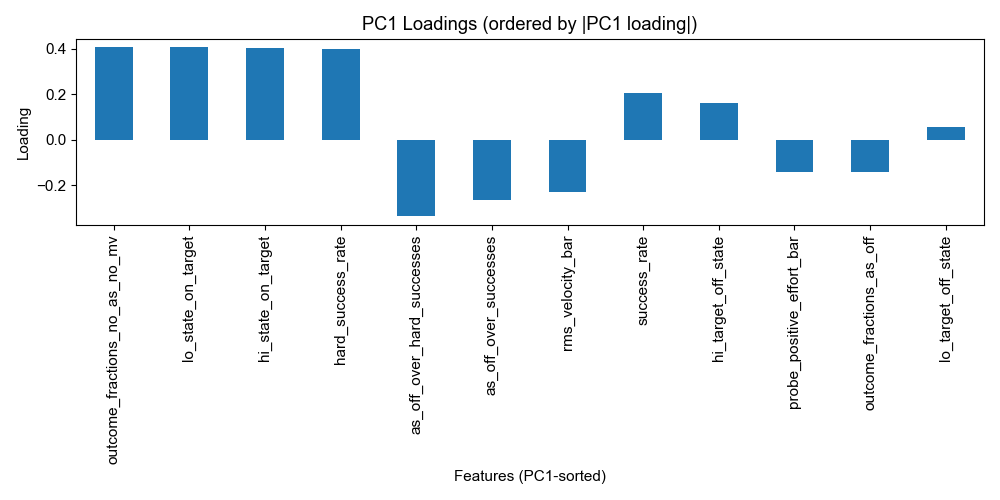

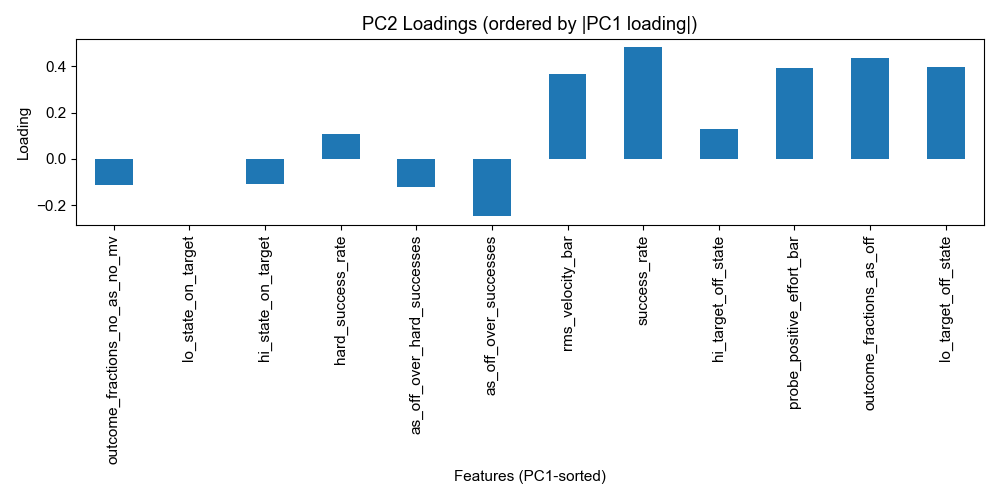

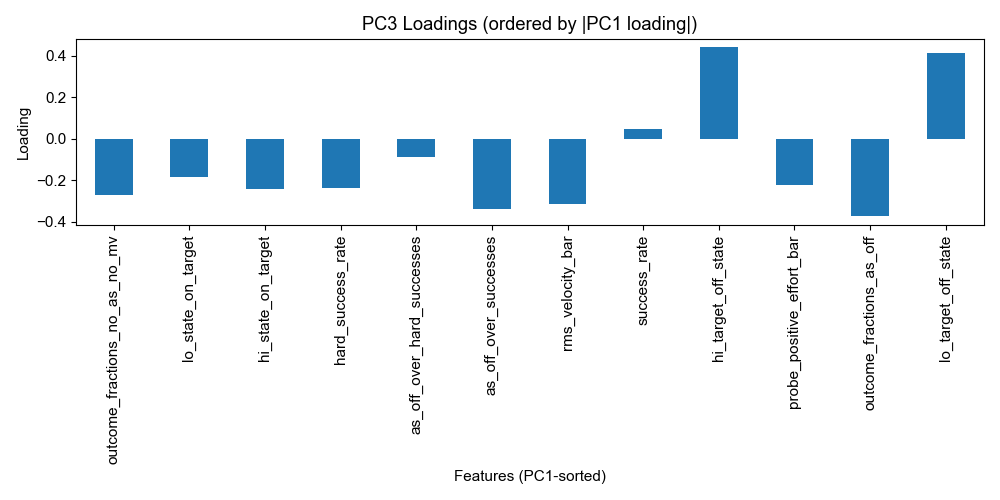

In [18]:
loadings = pd.DataFrame(
    pca.components_,
    index=[f"PC{i+1}" for i in range(pca.n_components_)],
    columns=X.columns
)

# Optional: variance-scaled loadings (correlations) sometimes used for “importance”:
# These are eigenvectors scaled by sqrt(eigenvalues)
var_scaled_loadings = pd.DataFrame(
    (pca.components_.T * np.sqrt(pca.explained_variance_)).T,
    index=[f"PC{i+1}" for i in range(pca.n_components_)],
    columns=X.columns
)

# Canonical feature order: sorted by |PC1 loading|
pc1_order = loadings.loc["PC1"].abs().sort_values(ascending=False).index

for pc in ["PC1", "PC2", "PC3"]:
    pc_l = loadings.loc[pc].reindex(pc1_order)

    fig = plt.figure(figsize=(10, 5))
    pc_l.plot(kind="bar")
    plt.title(f"{pc} Loadings (ordered by |PC1 loading|)")
    plt.ylabel("Loading")
    plt.xlabel("Features (PC1-sorted)")
    plt.tight_layout()

    fig.savefig(f'./{control_dir}/{pc}_simplified.svg')

# # --- 4) Plot PC1 loadings sorted by absolute magnitude ---
# for pc in ["PC1",'PC2','PC3']:
#     pc_l = loadings.loc[pc].sort_values(key=np.abs, ascending=False)

#     fig = plt.figure(figsize=(10, 5))
#     pc_l.plot(kind="bar")
#     plt.title(f"{pc} Loadings (feature weights)")
#     plt.ylabel("Loading")
#     plt.xlabel("Features (sorted by |loading|)")
#     plt.tight_layout()

#     # If you want the top-N features programmatically:
#     topN = 15
#     # pc1_top = pc_l.head(topN)
#     # print(pc1_top)
#     fig.savefig(f'./{control_dir}/{pc}_simplified.svg')

In [19]:
pc_l
np.linalg.norm(pc_l)


np.float64(0.9999999999999996)

# LDA on the above factors

In [20]:
# lda_df = op_df.loc[op_df['learn_class']<2]
# lda_df['learn_class']

lda_df = op_df.copy()
lda_df['control'] = lda_df['control'].map({True:0,False:1})
# lda_df['control'].astype(int).values

In [21]:
labels = ['geno_smpl','learn_class','learn','note_text']

factors = [
    'outcome_fractions_no_as_no_mv',        # pc1, 3
    #'outcome_fractions_no_as_mv',          # pc3, 2
    'outcome_fractions_as_off',            # pc2, 1
    #'outcome_fractions_as_off_late',
    #'outcome_fractions_timeout',           # pc2, 4
    #'hi_lo_shift',
    'lo_state_on_target',                   # pc1, 2
    'hi_state_on_target',                   # pc1, 1
    'lo_target_off_state',                  # pc3, 1
    'hi_target_off_state',                  # pc3, 4
    'success_rate',                         # pc2, 5
    'hard_success_rate',                    # pc1, 4
    'as_off_over_successes',                # pc3, 4
    'as_off_over_hard_successes',           # pc1, 5
    'rms_velocity_bar',                     # pc2, 3
    #'holding_cost_bar',
    'probe_positive_effort_bar',            # pc2, 2, pc3, 5
]

X = lda_df[factors].values
y = lda_df['control'].astype(int).values

X_ = op_df[factors].values
y_ = op_df['control'].astype(int).values

scaler = StandardScaler()
x_scaled = scaler.fit_transform(X,)
x_scaled_ = scaler.fit_transform(X_,)

pca = PCA(n_components=10,
          copy=True, 
          whiten=False, 
          svd_solver='full', 
          tol=0.0, 
          iterated_power='auto')
Z = pca.fit_transform(x_scaled)
Z_ = pca.fit_transform(x_scaled_)

In [22]:
import numpy as np
import pandas as pd
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, roc_auc_score

# --- 1) Fit LDA in the PCA space
lda = LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")
lda.fit(Z, y)

# Binary LDA => one row in coef_
w_pc = lda.coef_.ravel()                 # direction in PC space (not unit)
b_pc = lda.intercept_.item()             # bias in PC space
w_pc_unit = w_pc / np.linalg.norm(w_pc)  # unit vector (direction only)

# Discriminant scores and predictions using the true linear form
scores = Z @ w_pc + b_pc                 # same as lda.decision_function(Z)
y_pred = (scores >= 0).astype(int)

print("Acc:", accuracy_score(y, y_pred))
print("ROC-AUC:", roc_auc_score(y, scores))

# --- 2) (Optional) Project onto the *unit* axis if you prefer a centered 1D view
scores_unit = Z @ w_pc_unit
# Class means along the unit axis (for plotting/intuition)
mu0 = scores_unit[y==0].mean()
mu1 = scores_unit[y==1].mean()

# --- 3) Map direction back to original features
# PCA components_: shape (n_pcs, n_features); rows are PC loadings
V = pca.components_                      # (k, p) here k=3, p=len(factors)
# Direction in original (scaled) feature space:
w_orig_scaled = V.T @ w_pc_unit          # (p,)

# If you want *raw units*, undo the StandardScaler scaling
w_orig_raw = w_orig_scaled / scaler.scale_
w_orig_raw /= np.linalg.norm(w_orig_raw) # unit vector in raw units

# Nice, readable series
w_scaled_s = pd.Series(w_orig_scaled, index=factors).sort_values(ascending=False)
w_raw_s    = pd.Series(w_orig_raw,    index=factors).sort_values(ascending=False)

print("\nTop drivers (scaled feature space):")
display(w_scaled_s.head(10))
print("\nTop drivers (raw units):")
display(w_raw_s.head(10))

# --- 4) Handy objects you might reuse
lda_results = {
    "w_pc": w_pc,               # discriminant direction (PC space)
    "b_pc": b_pc,               # intercept
    "w_pc_unit": w_pc_unit,     # unit direction (PC space)
    "scores": scores,           # linear discriminant scores (w·z + b)
    "scores_unit": scores_unit, # projection on unit axis (no intercept)
    "y_pred": y_pred,
    "w_orig_scaled": w_orig_scaled,  # feature contributions (scaled space)
    "w_orig_raw": w_orig_raw,        # feature contributions (raw units)
    'scaler':       x_scaled_,  # for scaling mutants
    'pcamodel':     pca,        # pca model for transforming factors
    'lda':          lda         # lda model fit to pcs.
}


Acc: 0.847457627118644
ROC-AUC: 0.956876456876457

Top drivers (scaled feature space):


hi_state_on_target               0.494079
lo_state_on_target               0.487165
outcome_fractions_no_as_no_mv    0.445819
success_rate                     0.209030
hi_target_off_state              0.133624
outcome_fractions_as_off         0.106427
hard_success_rate                0.068824
lo_target_off_state             -0.095445
probe_positive_effort_bar       -0.115363
as_off_over_successes           -0.243153
dtype: float64


Top drivers (raw units):


success_rate                     0.687518
hard_success_rate                0.456312
outcome_fractions_no_as_no_mv    0.198489
lo_state_on_target               0.169062
hi_state_on_target               0.160902
hi_target_off_state              0.144611
outcome_fractions_as_off         0.054189
probe_positive_effort_bar       -0.000002
rms_velocity_bar                -0.000478
as_off_over_hard_successes      -0.045137
dtype: float64

If you just take raw units

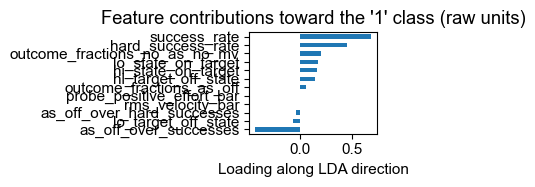

In [23]:
ftrfig = Figure(figsize=(4,2))
# plt.figure(figsize=(5,5))
ftrax = ftrfig.add_subplot(1, 1, 1)

ftrax = w_raw_s.plot(kind="barh", ax=ftrax)
ftrax.set_title("Feature contributions toward the '1' class (raw units)")
ftrax.set_xlabel("Loading along LDA direction")
ftrax.invert_yaxis()
ftrfig.tight_layout()
display(ftrfig)

### but if you take the scaled versions

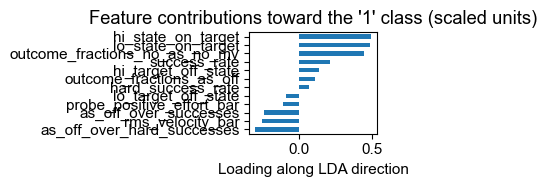

In [24]:
ftrfig = Figure(figsize=(4,2))
# plt.figure(figsize=(5,5))
ftrax = ftrfig.add_subplot(1, 1, 1)

ftrax = w_scaled_s.plot(kind="barh", ax=ftrax)
ftrax.set_title("Feature contributions toward the '1' class (scaled units)")
ftrax.set_xlabel("Loading along LDA direction")
ftrax.invert_yaxis()
ftrfig.tight_layout()
display(ftrfig)
ftrfig.savefig(fname=f'./{control_dir}/LDA_w_scaled.svg',format='svg')

In [25]:
np.linalg.norm(w_scaled_s)


np.float64(0.9999999999999998)

In [26]:
w_pc_unit

array([ 0.89312639, -0.01298331, -0.13955017,  0.12309596,  0.0707923 ,
       -0.02383125, -0.04678102,  0.03785705,  0.27145813, -0.29092817])

In [27]:
tags = sinq.all_tags()
print(tags)

['1s_stim', 'Figure1', 'control', 'cumulative_punishment_250228_F2_C1.mat', 'easy_targets', 'extension', 'late_learn', 'learn', 'no_antenna', 'no_cue', 'no_learn', 'norpa', 'replay', 'vnc_cut']


In [28]:
expts = [
    '1s_stim',
    'replay',
    'norpa',
    ['norpa','no_antenna'],
    'easy_targets',
    'no_antenna',
    'vnc_cut'
]

In [29]:
for pc2idx in [2]: # [1,2]:
    pc12 = Z_[:,[0,pc2idx]]
    op_df["PC1"] = Z_[:,0]
    op_df["PC2"] = Z_[:,pc2idx]

    origin = pc12.mean(axis=0)
    # w2 = w_pc_unit[:2]
    w2 = w_pc[[0,pc2idx]]

    scale = 2.0 * pc12.std(0).mean()

    # decision boundary: {z : w·z + b = 0} → line with normal w2
    # pick a point x0 on the boundary in 2D by solving w2·x0 + (w_pc[2:]*mean(others) + b) ≈ 0
    # Since we're only plotting (PC1, PC2), treat other PCs at their means (≈0 after PCA).
    b2 = b_pc  # others ~ 0 in Z, so intercept stays b
    # Point on line: x0 = -b2 * w2 / ||w2||^2
    x0 = -b2 * w2 / (np.linalg.norm(w2)**2 + 1e-12)
    # Direction along the line is perpendicular to w2:
    v = np.array([-w2[1], w2[0]])
    t = np.linspace(-2, 2, 200)
    line = x0[None,:] + t[:,None]*v[None,:]

    op_df["_tags_str"] = op_df["tags"].apply(
        lambda t: ", ".join([t]) if t else ""
    )

    op_df["_hover"] = (
        "index: " + op_df.index.astype(str)
        + "<br>tags: " + op_df["_tags_str"]
    )

    import plotly.graph_objects as go

    color_map = {
        0: "#000000",   # blue
        1: "#989898",   # orange
        2: "#484848",   # orange
    }

    color_map = {
        False: "#000000",   # blue
        True: "#989898",   # orange
    }

    for expt in expts:
        
        fig = go.Figure()

        fig.add_trace(
            go.Scatter(
                x=op_df["PC1"],
                y=op_df["PC2"],
                mode="markers",
                marker=dict(
                    size=8,
                    color=op_df["control"].map(color_map),
                    opacity=0.7,
                ),
                hovertext=op_df["_hover"],
                hoverinfo="text",
                name="All points",
            )
        )

        labels = sinq.rows_with_tags(expt)
        print(f'Plotting {len(labels)} flies in {expt} experiments')
        sel_df = op_df.loc[labels]

        fig.add_trace(
            go.Scatter(
                x=sel_df["PC1"],
                y=sel_df["PC2"],
                mode="markers",
                marker=dict(
                    size=9,
                    color="#FFB000",
                    opacity=0.95,
                ),
                hovertext=sel_df["_hover"],
                hoverinfo="text",
                name=f"tagged: {expt}",
            )
        )

        fig.add_trace(
            go.Scatter(
                x=[origin[0], origin[0] + scale * w2[0]],
                y=[origin[1], origin[1] + scale * w2[1]],
                mode="lines+markers",
                line=dict(width=3),
                name="LDA direction",
            )
        )
        fig.add_trace(
            go.Scatter(
                x=line[:, 0],
                y=line[:, 1],
                mode="lines",
                line=dict(dash="dash", width=2),
                name="decision boundary",
            )
        )
        fig.update_layout(
            title="LDA in PCA space",
            xaxis_title="PC1",
            yaxis_title="PC"+str(pc2idx+1),
            width=800,
            height=800,
            hovermode="closest",
        )

        fig.update_yaxes(scaleanchor="x", scaleratio=1)

        if isinstance(expt, str):
            es = expt
        elif isinstance(expt,list):
            es = '_'.join(expt)
        for fmt in ['html','svg','png']:
            fmt_dir = f"./{control_dir}/expts_in_LDA_space/{fmt}"
            os.makedirs(fmt_dir,exist_ok=True)
            fname = f"{fmt_dir}/LDA_in_PC1_PC{pc2idx+1}_{es}.{fmt}"
            if fmt=='html': 
                fig.write_html(fname)
            else:
                fig.write_image(fname)

Plotting 4 flies in 1s_stim experiments
Plotting 7 flies in replay experiments
Plotting 10 flies in norpa experiments
Plotting 6 flies in ['norpa', 'no_antenna'] experiments
Plotting 1 flies in easy_targets experiments
Plotting 9 flies in no_antenna experiments
Plotting 7 flies in vnc_cut experiments


In [30]:
display(fig)

In [31]:
np.linalg.norm(w_pc_unit)

np.float64(0.9999999999999999)

In [32]:
sinq.rows_with_tags('replay')

['251113_F1_C1',
 '251113_F2_C1',
 '251126_F1_C1',
 '251203_F1_C1',
 '251203_F2_C1',
 '251205_F1_C1',
 '251205_F2_C1']

In [33]:
# from sklearn.metrics import roc_curve
# fpr, tpr, thr = roc_curve(y, scores)
# j = tpr - fpr
# threshold = thr[np.argmax(j)]  # Youden's J

# # Predicted class by the 1D rule
# y_pred = (scores >= threshold).astype(int)
# y_pred

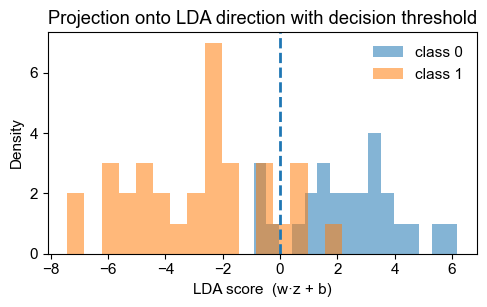

In [34]:
# scores = lda.decision_function(Z)  # = Z @ w_pc + b, 1D array
scores = lda.decision_function(Z_)  # = Z @ w_pc + b, 1D array
op_df['lda_scores'] = scores
thr = 0.0

# fig, ax = plt.subplots(figsize=(5,3.2))
hstfig = Figure(figsize=(5,3.2))
# plt.figure(figsize=(5,5))
hstrax = hstfig.add_subplot(1, 1, 1)

for cls in (0, 1):
    # hstrax.hist(scores[y==cls], bins=16,  alpha=0.55, label=f"class {cls}")
    _, bins,_ = hstrax.hist(scores[y_==cls], bins=16,  alpha=0.55, label=f"class {cls}")

hstrax.axvline(thr, linestyle="--", linewidth=2)
hstrax.set_xlabel("LDA score  (w·z + b)")
hstrax.set_ylabel("Density")
hstrax.legend(frameon=False)
hstrax.set_title("Projection onto LDA direction with decision threshold")
hstfig.tight_layout()
display(hstfig)
hstfig.savefig(f'./{control_dir}/flies_onto_LDA.svg')

In [35]:
op_df.columns

Index(['Table', 'parquet', 'genotype', 'notes', 'note_text', 'tags',
       'duration', 'rms_velocity', 'outcome_fractions_no_as_no_mv',
       'outcome_fractions_as_off', 'outcome_fractions_rest',
       'outcome_fractions_no_as_mv', 'outcome_fractions_probe',
       'outcome_fractions_as_off_late', 'outcome_fractions_timeout_fail',
       'outcome_fractions_timeout', 'outcome_fractions_info',
       'lo_state_median_position', 'hi_state_median_position', 'hi_lo_shift',
       'hi_state_on_target', 'lo_state_on_target', 'num_trials',
       'blue_fraction', 'blue_toggle_fraction', 'most_common_fiberLED',
       'lo_target_off_state', 'hi_target_off_state', 'probe_positive_effort',
       'successes', 'hard_successes', 'holding_cost', 'learn', 'control',
       'geno_smpl', 'learn_class', 'success_rate', 'hard_success_rate',
       'as_off_over_successes', 'as_off_over_hard_successes',
       'rms_velocity_bar', 'holding_cost_bar', 'probe_positive_effort_bar',
       'PC1', 'PC2', '_ta

In [36]:
op_df.loc[op_df['lda_scores']>=0,['lda_scores','tags','learn','note_text']]

,lda_scores,tags,learn,note_text
210302_F1_C2,6.187186,"Figure1, learn",True,na\n\n
210331_F2_C1,0.762965,"Figure1, no_learn",False,Seems like it should be learning
210405_F1_C1,2.984834,"Figure1, learn",True,"Long timeout, many timeouts"
210604_F1_C1,3.290455,"Figure1, learn",True,"Long timeout, super learner"
210903_F3_C1,2.320703,"Figure1, learn",True,"Long timeouts, ignores red, missing later blocks"
210915_F1_C1,1.727527,"Figure1, learn",True,na
210917_F2_C1,2.685631,"Figure1, learn",True,na
250226_F2_C1,1.830565,"Figure1, no_learn",False,"Never got it, tried hard"
250227_F2_C1,3.242485,"Figure1, learn",True,na
250227_F3_C1,0.898211,"Figure1, learn",True,na


# Show a couple of examples across the border

In [37]:
'251107_F2_C1'
'251103_F2_C1'

'251103_F2_C1'

In [38]:
op_df.loc[['251107_F2_C1','251103_F2_C1'],['lda_scores','tags','learn','note_text']]

,lda_scores,tags,learn,note_text
251107_F2_C1,2.158740,"1s_stim, control, learn",True,Constant 1s stim
251103_F2_C1,-2.540681,"1s_stim, control",False,Constant 1s stim


# What about the extension flies?

In [39]:
# lda_df = op_df.loc[op_df['learn_class']<2]
# lda_df['learn_class']

ex_df = op_df_0.loc[sinq.has_tag('extension')].copy()
lda_df = ex_df.copy()
# lda_df['control']
# lda_df['control'] = lda_df['control'].map({True:0,False:1})
# lda_df['control'].astype(int).values

In [40]:
lda_df

,Table,parquet,genotype,notes,note_text,tags,duration,rms_velocity,outcome_fractions_no_as_no_mv,outcome_fractions_as_off,...,control,geno_smpl,learn_class,success_rate,hard_success_rate,as_off_over_successes,as_off_over_hard_successes,rms_velocity_bar,holding_cost_bar,probe_positive_effort_bar
260619_F1_C1,None,LEDFlashTriggerPiezoControl_260619_F1_C1_Table...,+;SS61350_pJFRC7,"{'text': '', 'tags': ['control', 'extension'],...",,"control, extension",8459.55954,1.054157e+06,0.0,0.827119,...,True,+,1.0,0.074576,0.0,0.042763,2.865104,124.611342,3142.148715,58.521856
260619_F2_C1,None,LEDFlashTriggerPiezoControl_260619_F2_C1_Table...,+;SS61350_pJFRC7,"{'text': '', 'tags': ['control', 'extension'],...",,"control, extension",7807.61566,4.832416e+06,0.0,0.881563,...,True,+,1.0,0.034188,0.0,0.098591,2.859138,618.936226,2255.573378,6805.121518
260623_F1_C1,None,LEDFlashTriggerPiezoControl_260623_F1_C1_Table...,+;pJFRC7_+;81A06-Gal4_+,"{'text': '', 'tags': ['control', 'extension'],...",,"control, extension",5133.93192,2.402739e+05,0.0,0.464455,...,True,+,1.0,0.016588,0.0,0.286808,2.294466,46.801148,1147.249293,1.731485
260623_F2_C1,None,LEDFlashTriggerPiezoControl_260623_F2_C1_Table...,+;pJFRC7_+;81A06-Gal4_+,"{'text': '', 'tags': ['control', 'extension'],...",,"control, extension",10186.54960,4.659466e+05,0.0,0.474616,...,True,+,1.0,0.012987,0.0,0.217109,2.605305,45.741356,698.669126,6.308170
260623_F3_C1,None,LEDFlashTriggerPiezoControl_260623_F3_C1_Table...,+;pJFRC7_+;81A06-Gal4_+,"{'text': '', 'tags': ['control', 'extension'],...",,"control, extension",4771.98366,3.710125e+05,0.0,0.698312,...,True,+,1.0,0.118143,0.0,0.044230,2.521138,77.748072,3003.690310,4.435845


In [41]:
# g_df['geno_smpl'] = g_df['genotype'].map(gm_geno_map)
# g_df.loc[g_df['geno_smpl'].isna()]

# g_list = list(g_df['geno_smpl'].unique())
# g_list
ext_list = ['extension']

In [42]:
# Put the new data in to the same coordinates as before
X_ex = ex_df[factors].values
y_ex = ex_df['control'].astype(int).values

x_scaled_ex = scaler.transform(X_ex)

Z_ex = pca.transform(x_scaled_ex)

In [43]:
# Discriminant scores and predictions using the true linear form
scores_ex = Z_ex @ w_pc + b_pc                 # same as lda.decision_function(Z)
y_pred_ex = (scores >= 0).astype(int)

# --- 2) (Optional) Project onto the *unit* axis if you prefer a centered 1D view
scores_unit_ex = Z_ex @ w_pc_unit

In [44]:
def _get_gstr(g):
    g = g.replace('.', '_')
    g = g.replace('>', '_')
    g = g.replace('/', '_')
    g = g.replace('[', '')
    g = g.replace(']', '')
    g = g.replace('*', '')
    return g

for pc2idx in [2]: # [1,2]:
    pc12 = Z_[:,[0,pc2idx]]
    op_df["PC1"] = Z_[:,0]
    op_df["PC2"] = Z_[:,pc2idx]

    pc12_g = Z_ex[:,[0,pc2idx]]
    ex_df["PC1"] = Z_ex[:,0]
    ex_df["PC2"] = Z_ex[:,pc2idx]

    origin = pc12.mean(axis=0)
    # w2 = w_pc_unit[:2]
    w2 = w_pc[[0,pc2idx]]

    scale = 2.0 * pc12.std(0).mean()

    # decision boundary: {z : w·z + b = 0} → line with normal w2
    # pick a point x0 on the boundary in 2D by solving w2·x0 + (w_pc[2:]*mean(others) + b) ≈ 0
    # Since we're only plotting (PC1, PC2), treat other PCs at their means (≈0 after PCA).
    b2 = b_pc  # others ~ 0 in Z, so intercept stays b
    # Point on line: x0 = -b2 * w2 / ||w2||^2
    x0 = -b2 * w2 / (np.linalg.norm(w2)**2 + 1e-12)
    # Direction along the line is perpendicular to w2:
    v = np.array([-w2[1], w2[0]])
    t = np.linspace(-2, 2, 200)
    line = x0[None,:] + t[:,None]*v[None,:]

    ex_df["_tags_str"] = ex_df["geno_smpl"].apply(
        lambda t: ", ".join([t]) if t else ""
    )

    ex_df["_hover"] = (
        "index: " + ex_df.index.astype(str)
        + "<br>tags: " + ex_df["_tags_str"]
    )

    color_map = {
        0: "#000000",   # blue
        1: "#989898",   # orange
        2: "#484848",   # orange
    }

    color_map = {
        False: "#000000",   # blue
        True: "#989898",   # orange
    }

    for ex_smpl in ext_list:
        
        fig = go.Figure()

        # controls
        fig.add_trace(
            go.Scatter(
                x=op_df["PC1"],
                y=op_df["PC2"],
                mode="markers",
                marker=dict(
                    size=8,
                    color=op_df["control"].map(color_map),
                    opacity=0.7,
                ),
                hovertext=op_df["_hover"],
                hoverinfo="text",
                name="All points",
            )
        )
        
        # all mutants
        fig.add_trace(
            go.Scatter(
                x=ex_df["PC1"],
                y=ex_df["PC2"],
                mode="markers",
                marker=dict(
                    size=8,
                    color="#00C8C8",
                    opacity=0.7,
                ),
                hovertext=ex_df["_hover"],
                hoverinfo="text",
                name="All points",
            )
        )

        # labels = sinq.rows_with_tags(expt)
        # g_idx = ex_df[ex_df['geno_smpl']==g_smpl].index
        ex_idx = ex_df.index
        print(f'Plotting {len(ex_idx)} flies in {ex_smpl} experiments')
        sel_df = ex_df.loc[ex_idx]

        fig.add_trace(
            go.Scatter(
                x=sel_df["PC1"],
                y=sel_df["PC2"],
                mode="markers",
                marker=dict(
                    size=9,
                    color="#FFB000",
                    opacity=0.95,
                ),
                hovertext=sel_df["_hover"],
                hoverinfo="text",
                name=f"tagged: {ex_smpl}",
            )
        )

        fig.add_trace(
            go.Scatter(
                x=[origin[0], origin[0] + scale * w2[0]],
                y=[origin[1], origin[1] + scale * w2[1]],
                mode="lines+markers",
                line=dict(width=3),
                name="LDA direction",
            )
        )
        fig.add_trace(
            go.Scatter(
                x=line[:, 0],
                y=line[:, 1],
                mode="lines",
                line=dict(dash="dash", width=2),
                name="decision boundary",
            )
        )
        fig.update_layout(
            title="LDA in PCA space",
            xaxis_title="PC1",
            yaxis_title="PC"+str(pc2idx+1),
            width=800,
            height=800,
            hovermode="closest",
        )

        fig.update_yaxes(scaleanchor="x", scaleratio=1)
        fig.update_xaxes(range=[-6, 5])
        fig.update_yaxes(range=[-3, 3])

        if isinstance(ex_smpl, str):
            exs = _get_gstr(ex_smpl)
        elif isinstance(ex_smpl,list):
            exs = _get_gstr('_'.join(ex_smpl))

        for fmt in ['html','svg','png']:
            fmt_dir = f"./{control_dir}/expts_in_LDA_space/{fmt}"
            os.makedirs(fmt_dir,exist_ok=True)
            fname = f"{fmt_dir}/LDA_in_PC1_PC{pc2idx+1}_{exs}.{fmt}"
            if fmt=='html': 
                fig.write_html(fname)
            else:
                fig.write_image(fname)

Plotting 5 flies in extension experiments


In [45]:
ex_df["_tags_str"].head()

260619_F1_C1    +
260619_F2_C1    +
260623_F1_C1    +
260623_F2_C1    +
260623_F3_C1    +
Name: _tags_str, dtype: object

In [46]:
display(fig)

# Import mutant sinq and select other rows

In [47]:
sinq_g = Sinq(sinqname='dataset_3_genetic_manipulations')
print(sinq_g.__repr__())

Found data directory: D:\Data
Sinq(dataset_3_genetic_manipulations, 34 rows x 30 params): 34 empties; ['241205_F2_C1', '241205_F3_C1', '241219_F1_C1', '241219_F2_C1', '241220_F1_C1', '241220_F2_C1', '250127_F1_C1', '250127_F2_C1', '250128_F1_C1', '250204_F1_C1', '250204_F2_C1', '250211_F2_C1', '250211_F3_C1', '250317_F1_C1', '250317_F2_C1', '250318_F1_C1', '250318_F2_C1', '250318_F3_C1', '250320_F1_C1', '250320_F2_C1', '250325_F1_C1', '250423_F1_C1', '250423_F2_C1', '250507_F1_C1', '250507_F2_C1', '250509_F1_C1', '250509_F2_C1', '250515_F1_C1', '251114_F1_C2', '260527_F1_C1', '260527_F4_C1', '260605_F1_C1', '260605_F2_C1', '260605_F3_C1'] x ['Table', 'parquet', 'genotype', 'notes', 'duration', 'rms_velocity', 'outcome_fractions_no_as_no_mv', 'outcome_fractions_as_off', 'outcome_fractions_rest', 'outcome_fractions_no_as_mv', 'outcome_fractions_probe', 'outcome_fractions_as_off_late', 'outcome_fractions_timeout_fail', 'outcome_fractions_timeout', 'outcome_fractions_info', 'lo_state_media

In [48]:
g_idx = sinq_g.df.loc[(sinq_g.df.index.isin(sinq.df.index))].index
g_idx
# sinq_g = subset_sinq(source=sinq_g,rows=g_idx,name='Figure6_mutant_pca')

Index([], dtype='object')

In [49]:
sinq_g.df

,Table,parquet,genotype,notes,duration,rms_velocity,outcome_fractions_no_as_no_mv,outcome_fractions_as_off,outcome_fractions_rest,outcome_fractions_no_as_mv,...,num_trials,blue_fraction,blue_toggle_fraction,most_common_fiberLED,lo_target_off_state,hi_target_off_state,probe_positive_effort,successes,hard_successes,holding_cost
241205_F2_C1,None,LEDFlashTriggerPiezoControl_241205_F2_C1_Table...,iav_Kir2_1,None,4592.04334,1.037038e+05,0.083984,0.630859,0.152344,0.103516,...,512.0,1.000000,1.0,epi_only,0.371842,0.024624,3.129737e+06,64.0,8.0,5.745730e+06
241205_F3_C1,None,LEDFlashTriggerPiezoControl_241205_F3_C1_Table...,iav_Kir2_1,None,4601.99376,1.995216e+05,0.003891,0.762646,0.155642,0.042802,...,514.0,1.000000,1.0,epi_only,0.264464,0.049193,6.841562e+06,20.0,0.0,7.592188e+06
241219_F1_C1,None,LEDFlashTriggerPiezoControl_241219_F1_C1_Table...,iav_Kir2_1,None,8427.33492,2.468955e+05,0.000000,0.759193,0.151839,0.000000,...,843.0,0.053381,1.0,epi_only,0.145026,0.023368,6.295168e+06,0.0,0.0,8.077882e+06
241219_F2_C1,None,LEDFlashTriggerPiezoControl_241219_F2_C1_Table...,iav_Kir2_1,None,5633.13292,1.485294e+05,0.000000,0.703642,0.172185,0.024834,...,604.0,0.000000,1.0,epi_only,0.212010,0.043292,4.128245e+06,14.0,0.0,6.042135e+06
241220_F1_C1,None,LEDFlashTriggerPiezoControl_241220_F1_C1_Table...,iav_Kir2_1,None,6633.59082,2.480747e+05,0.000000,0.798077,0.153846,0.015110,...,728.0,0.000000,1.0,epi_only,0.221039,0.027496,6.949634e+06,11.0,0.0,8.077262e+06
241220_F2_C1,None,LEDFlashTriggerPiezoControl_241220_F2_C1_Table...,iav_Kir2_1,None,7837.07546,2.913358e+05,0.007212,0.713942,0.153846,0.037260,...,832.0,0.312500,1.0,epi_only,0.213848,0.023861,8.781938e+06,28.0,0.0,1.333849e+07
250127_F1_C1,None,LEDFlashTriggerPiezoControl_250127_F1_C1_Table...,31H05_pJFRC7,None,6800.32020,3.596394e+05,0.027510,0.707015,0.154058,0.049519,...,727.0,0.433287,1.0,epi_only,0.171928,0.039667,8.867315e+06,42.0,3.0,7.057058e+06
250127_F2_C1,None,LEDFlashTriggerPiezoControl_250127_F2_C1_Table...,31H05_pJFRC7,None,5484.01952,3.742404e+05,0.033670,0.680135,0.146465,0.069024,...,594.0,0.304714,1.0,epi_only,0.090299,0.055188,1.212134e+07,34.0,2.0,7.109523e+06
250128_F1_C1,None,LEDFlashTriggerPiezoControl_250128_F1_C1_Table...,31H05_pJFRC7,None,6574.20504,5.108770e+05,0.098901,0.649725,0.153846,0.083791,...,728.0,0.285714,1.0,epi_only,0.122484,0.046467,2.343239e+07,54.0,8.0,2.088457e+07
250204_F1_C1,None,LEDFlashTriggerPiezoControl_250204_F1_C1_Table...,31H05_pJFRC7,None,7588.12330,3.860837e+05,0.112965,0.541720,0.138639,0.134788,...,779.0,0.261874,1.0,epi_only,0.205880,0.090884,1.855656e+07,100.0,15.0,1.836187e+07


In [50]:
g_df = sinq_g.display_df(show_tags=True)
g_df['learn'] = sinq.has_tag('learn')
g_df['control'] = sinq.has_tag('control')
g_df[['genotype','tags','learn','control']]

,genotype,tags,learn,control
241205_F2_C1,iav_Kir2_1,,NaN,NaN
241205_F3_C1,iav_Kir2_1,,NaN,NaN
241219_F1_C1,iav_Kir2_1,,NaN,NaN
241219_F2_C1,iav_Kir2_1,,NaN,NaN
241220_F1_C1,iav_Kir2_1,,NaN,NaN
241220_F2_C1,iav_Kir2_1,,NaN,NaN
250127_F1_C1,31H05_pJFRC7,,NaN,NaN
250127_F2_C1,31H05_pJFRC7,,NaN,NaN
250128_F1_C1,31H05_pJFRC7,,NaN,NaN
250204_F1_C1,31H05_pJFRC7,,NaN,NaN


In [51]:
# print([i for i in op_df['genotype'].unique()])
list(g_df['genotype'].unique())

['iav_Kir2_1',
 '31H05_pJFRC7',
 'iav-Gal4_+;+;UAS-Kir2_1',
 '+;iav-Gal4_UAS-Kir2_1',
 '+;TH-Gal4_UAS-Kir2_1',
 '+;TH-Gal4_pJFRC7',
 '+;UAS-TeTx;58E02-GAL4',
 'PPL1_Tetx',
 '+;UAS-TeTx;58E02-Gl4']

In [ ]:
gm_geno_map = {
 'iav_Kir2_1':                      'w;iav>kir2.1',
 '31H05_pJFRC7':                    'w',
 'iav-Gal4_+;+;UAS-Kir2_1':         '+;iav>kir2.1',
 '+;iav-Gal4_UAS-Kir2_1':           '+;iav>kir2.1',
 '+;31H05-Gal4_pJFRC7':             '+',
 '+;TH-Gal4_UAS-Kir2_1':            '+;TH>kir2.1',
 '+;TH-Gal4_pJFRC7':                '+',
 '+;UAS-TeTx;58E02-GAL4':           '+;UAS-TeTx;58E02-GAL4',
 'PPL1_Tetx':                       '+;MB504B>UAS-TeTx',
 '+;UAS-TeTx;58E02-Gl4':            '+;UAS-TeTx;58E02-GAL4',
 
 }

g_df['geno_smpl'] = g_df['genotype'].map(gm_geno_map)
g_df.loc[g_df['geno_smpl'].isna()]

g_list = list(g_df['geno_smpl'].unique())
g_list

['w;iav>kir2.1',
 'w',
 '+;iav>kir2.1',
 '+;TH>kir2.1',
 '+',
 '+;UAS-TeTx;58E02-GAL4',
 nan]

## Additional factors

In [ ]:
g_df['learn'] = 2  # Control
g_df['control'] = False
g_df['learn_class'] = 3 # testing if they are learners or not

In [ ]:
g_df['success_rate'] =         g_df['successes'] / g_df['num_trials']
g_df['hard_success_rate'] =    g_df['hard_successes'] / g_df['num_trials']

g_df['as_off_over_successes'] =        np.log10(g_df['outcome_fractions_as_off'] * g_df['num_trials'] + 1) / (g_df['successes'] + 1)
g_df['as_off_over_hard_successes'] =   np.log10(g_df['outcome_fractions_as_off'] * g_df['num_trials'] + 1) / (g_df['hard_successes'] + 1)

g_df['rms_velocity_bar'] = g_df['rms_velocity'] / g_df['duration']
g_df['holding_cost_bar'] = g_df['holding_cost'] / g_df['duration']
g_df['probe_positive_effort_bar'] = g_df['probe_positive_effort'] / g_df['duration']

# Project mutants into same space with LDA

In [ ]:
# lda_df = op_df.loc[op_df['learn_class']<2]
# lda_df['learn_class']

lda_df = g_df.copy()
# lda_df['control'] = lda_df['control'].map({True:0,False:1})
# lda_df['control'].astype(int).values

In [ ]:
labels = ['geno_smpl','learn_class','learn','note_text']

factors = [
    'outcome_fractions_no_as_no_mv',        # pc1, 3
    #'outcome_fractions_no_as_mv',          # pc3, 2
    'outcome_fractions_as_off',            # pc2, 1
    #'outcome_fractions_as_off_late',
    #'outcome_fractions_timeout',           # pc2, 4
    #'hi_lo_shift',
    'lo_state_on_target',                   # pc1, 2
    'hi_state_on_target',                   # pc1, 1
    'lo_target_off_state',                  # pc3, 1
    'hi_target_off_state',                  # pc3, 4
    'success_rate',                         # pc2, 5
    'hard_success_rate',                    # pc1, 4
    'as_off_over_successes',                # pc3, 4
    'as_off_over_hard_successes',           # pc1, 5
    'rms_velocity_bar',                     # pc2, 3
    #'holding_cost_bar',
    'probe_positive_effort_bar',            # pc2, 2, pc3, 5
]

# Put the new data in to the same coordinates as before
X_g = g_df[factors].values
y_g = g_df['control'].astype(int).values

x_scaled_g = scaler.transform(X_g)

Z_g = pca.transform(x_scaled_g)

In [ ]:
### ------ Don't need most of this because it's been done ------

# --- 1) Fit LDA in the PCA space
# lda = LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")
# lda.fit(Z, y)

# Binary LDA => one row in coef_
# w_pc = lda.coef_.ravel()                 # direction in PC space (not unit)
# b_pc = lda.intercept_.item()             # bias in PC space
# w_pc_unit = w_pc / np.linalg.norm(w_pc)  # unit vector (direction only)

# Discriminant scores and predictions using the true linear form
scores_g = Z_g @ w_pc + b_pc                 # same as lda.decision_function(Z)
y_pred_g = (scores >= 0).astype(int)

# print("Acc:", accuracy_score(y, y_pred))
# print("ROC-AUC:", roc_auc_score(y, scores))

# --- 2) (Optional) Project onto the *unit* axis if you prefer a centered 1D view
scores_unit_g = Z_g @ w_pc_unit
# Class means along the unit axis (for plotting/intuition)
# mu0 = scores_unit[y==0].mean()
# mu1 = scores_unit[y==1].mean()

# --- 3) Map direction back to original features
# PCA components_: shape (n_pcs, n_features); rows are PC loadings
# V = pca.components_                      # (k, p) here k=3, p=len(factors)
# Direction in original (scaled) feature space:
# w_orig_scaled = V.T @ w_pc_unit          # (p,)

# If you want *raw units*, undo the StandardScaler scaling
# w_orig_raw = w_orig_scaled / scaler.scale_
# w_orig_raw /= np.linalg.norm(w_orig_raw) # unit vector in raw units

# Nice, readable series
# w_scaled_s = pd.Series(w_orig_scaled, index=factors).sort_values(ascending=False)
# w_raw_s    = pd.Series(w_orig_raw,    index=factors).sort_values(ascending=False)

# print("\nTop drivers (scaled feature space):")
# display(w_scaled_s.head(10))
# print("\nTop drivers (raw units):")
# display(w_raw_s.head(10))

# --- 4) Handy objects you might reuse
# lda_results = {
#     "w_pc": w_pc,               # discriminant direction (PC space)
#     "b_pc": b_pc,               # intercept
#     "w_pc_unit": w_pc_unit,     # unit direction (PC space)
#     "scores": scores,           # linear discriminant scores (w·z + b)
#     "scores_unit": scores_unit, # projection on unit axis (no intercept)
#     "y_pred": y_pred,
#     "w_orig_scaled": w_orig_scaled,  # feature contributions (scaled space)
#     "w_orig_raw": w_orig_raw,        # feature contributions (raw units)
#     'scaler':       x_scaled_,  # for scaling mutants
#     'pcamodel':     pca,        # pca model for transforming factors
#     'lda':          lda         # lda model fit to pcs.
# }


In [ ]:
g_df["_tags_str"].head()

In [ ]:
def _get_gstr(g):
    g = g.replace('.', '_')
    g = g.replace('>', '_')
    g = g.replace('/', '_')
    g = g.replace('[', '')
    g = g.replace(']', '')
    g = g.replace('*', '')
    return g

for pc2idx in [2]: # [1,2]:
    pc12 = Z_[:,[0,pc2idx]]
    op_df["PC1"] = Z_[:,0]
    op_df["PC2"] = Z_[:,pc2idx]

    pc12_g = Z_g[:,[0,pc2idx]]
    g_df["PC1"] = Z_g[:,0]
    g_df["PC2"] = Z_g[:,pc2idx]

    origin = pc12.mean(axis=0)
    # w2 = w_pc_unit[:2]
    w2 = w_pc[[0,pc2idx]]

    scale = 2.0 * pc12.std(0).mean()

    # decision boundary: {z : w·z + b = 0} → line with normal w2
    # pick a point x0 on the boundary in 2D by solving w2·x0 + (w_pc[2:]*mean(others) + b) ≈ 0
    # Since we're only plotting (PC1, PC2), treat other PCs at their means (≈0 after PCA).
    b2 = b_pc  # others ~ 0 in Z, so intercept stays b
    # Point on line: x0 = -b2 * w2 / ||w2||^2
    x0 = -b2 * w2 / (np.linalg.norm(w2)**2 + 1e-12)
    # Direction along the line is perpendicular to w2:
    v = np.array([-w2[1], w2[0]])
    t = np.linspace(-2, 2, 200)
    line = x0[None,:] + t[:,None]*v[None,:]

    g_df["_tags_str"] = g_df["geno_smpl"].apply(
        lambda t: ", ".join([t]) if t else ""
    )

    g_df["_hover"] = (
        "index: " + g_df.index.astype(str)
        + "<br>tags: " + g_df["_tags_str"]
    )

    color_map = {
        0: "#000000",   # blue
        1: "#989898",   # orange
        2: "#484848",   # orange
    }

    color_map = {
        False: "#000000",   # blue
        True: "#989898",   # orange
    }

    for g_smpl in g_list:
        
        fig = go.Figure()

        # controls
        fig.add_trace(
            go.Scatter(
                x=op_df["PC1"],
                y=op_df["PC2"],
                mode="markers",
                marker=dict(
                    size=8,
                    color=op_df["control"].map(color_map),
                    opacity=0.7,
                ),
                hovertext=op_df["_hover"],
                hoverinfo="text",
                name="All points",
            )
        )
        
        # all mutants
        fig.add_trace(
            go.Scatter(
                x=g_df["PC1"],
                y=g_df["PC2"],
                mode="markers",
                marker=dict(
                    size=8,
                    color="#00C8C8",
                    opacity=0.7,
                ),
                hovertext=g_df["_hover"],
                hoverinfo="text",
                name="All points",
            )
        )

        # labels = sinq.rows_with_tags(expt)
        g_idx = g_df[g_df['geno_smpl']==g_smpl].index
        print(f'Plotting {len(g_idx)} flies in {g_smpl} experiments')
        sel_df = g_df.loc[g_idx]

        fig.add_trace(
            go.Scatter(
                x=sel_df["PC1"],
                y=sel_df["PC2"],
                mode="markers",
                marker=dict(
                    size=9,
                    color="#FFB000",
                    opacity=0.95,
                ),
                hovertext=sel_df["_hover"],
                hoverinfo="text",
                name=f"tagged: {g_smpl}",
            )
        )

        fig.add_trace(
            go.Scatter(
                x=[origin[0], origin[0] + scale * w2[0]],
                y=[origin[1], origin[1] + scale * w2[1]],
                mode="lines+markers",
                line=dict(width=3),
                name="LDA direction",
            )
        )
        fig.add_trace(
            go.Scatter(
                x=line[:, 0],
                y=line[:, 1],
                mode="lines",
                line=dict(dash="dash", width=2),
                name="decision boundary",
            )
        )
        fig.update_layout(
            title="LDA in PCA space",
            xaxis_title="PC1",
            yaxis_title="PC"+str(pc2idx+1),
            width=800,
            height=800,
            hovermode="closest",
        )

        fig.update_yaxes(scaleanchor="x", scaleratio=1)
        fig.update_xaxes(range=[-6, 5])
        fig.update_yaxes(range=[-3, 3])

        if isinstance(g_smpl, str):
            gs = _get_gstr(g_smpl)
        elif isinstance(g_smpl,list):
            gs = _get_gstr('_'.join(g_smpl))

        for fmt in ['html','svg','png']:
            fmt_dir = f"./{mutants_dir}/expts_in_LDA_space/{fmt}"
            os.makedirs(fmt_dir,exist_ok=True)
            fname = f"{fmt_dir}/LDA_in_PC1_PC{pc2idx+1}_{gs}.{fmt}"
            if fmt=='html': 
                fig.write_html(fname)
            else:
                fig.write_image(fname)

In [ ]:
display(fig)

In [ ]:
w_pc_unit

In [ ]:
np.linalg.norm(w_pc_unit)

In [ ]:
# from sklearn.metrics import roc_curve
# fpr, tpr, thr = roc_curve(y, scores)
# j = tpr - fpr
# threshold = thr[np.argmax(j)]  # Youden's J

# # Predicted class by the 1D rule
# y_pred = (scores >= threshold).astype(int)
# y_pred

In [ ]:
# scores = lda.decision_function(Z)  # = Z @ w_pc + b, 1D array
scores = lda.decision_function(Z_g)  # = Z @ w_pc + b, 1D array
g_df['lda_scores'] = scores
thr = 0.0

# fig, ax = plt.subplots(figsize=(5,3.2))
hstfig = Figure(figsize=(5,3.2))
# plt.figure(figsize=(5,5))
hstrax = hstfig.add_subplot(1, 1, 1)

for cls in (0, 1):
    # hstrax.hist(scores[y==cls], bins=16,  alpha=0.55, label=f"class {cls}")
    hstrax.hist(scores, bins=bins,  alpha=0.55, label=f"class {cls}")

hstrax.axvline(thr, linestyle="--", linewidth=2)
hstrax.set_xlabel("LDA score  (w·z + b)")
hstrax.set_ylabel("Density")
hstrax.legend(frameon=False)
hstrax.set_title("Projection onto LDA direction with decision threshold")
hstfig.tight_layout()
display(hstfig)
hstfig.savefig(f'./{mutants_dir}/flies_onto_LDA.svg')

In [ ]:
g_df.loc[g_df['lda_scores']>=0,['lda_scores','tags','learn','note_text']]

# Statistical testing:

## Shuffle the target positions in the data
Redo all the classifications, and plot in the same space!

## Drop 10% of the learning and control flies
Compare the directions in PC space of the discriminant

## Compare to including the genetic mutants

## Just look at the first few blocks of each fly

## Just switch the labels on learners vs. non-learners and compare discriminants (cosine similarity)

# Extras

# Compare factors, learners vs control vs. mutants

In [ ]:
learn_df = op_df.copy()
learn_df['is_mutant'] = False

mutant_df = g_df.copy()
mutant_df['is_mutant'] = True

all_df = pd.concat([learn_df,mutant_df])

def assign_condition(df):
    df = df.copy()

    # example assumptions – adapt to your actual column names
    # df["is_mutant"] : bool
    # df["lda_score"] : float
    # lda_score > 0 => learner
    is_learner = df["lda_scores"] > 0

    df["condition"] = np.select(
        condlist=[
            (~df["is_mutant"]) & (~is_learner),
            (~df["is_mutant"]) & (is_learner),
            (df["is_mutant"]) & (~is_learner),
            (df["is_mutant"]) & (is_learner),
        ],
        choicelist=[
            "Control",
            "Learner (WT)",
            "Non-learning mutant",
            "Learning mutant",
        ],
        default="Unknown"
    )

    df["condition"] = pd.Categorical(
        df["condition"],
        categories=[
            "Control",
            "Learner (WT)",
            "Non-learning mutant",
            "Learning mutant",
        ],
        ordered=True
    )

    return df

all_df = assign_condition(all_df)
all_df[['condition','geno_smpl']]

order = [
    "Control",
    "Learner (WT)",
    "Non-learning mutant",
    "Learning mutant",
]

colors = {
    "Control": "#4C72B0",
    "Learner (WT)": "#55A868",
    "Non-learning mutant": "#C44E52",
    "Learning mutant": "#DD8452",
}

In [ ]:
def prep_factor_df(df, factor_col, condition_col):
    dfx = df[[factor_col, condition_col, "tags"]].copy()
    dfx = dfx.dropna(subset=[factor_col, condition_col])
    dfx["_index"] = dfx.index

    def format_tags(tags):
        return ", ".join(tags) if isinstance(tags, (list, tuple)) else ""

    dfx["_tags_str"] = dfx["tags"].apply(format_tags)
    return dfx


def plot_factor_box(
    df,
    factor_col,
    condition_col="condition",
    order=None,
    colors=None,
    fig_dir=factor_plots_dir,
    title=None,
):
    dfx = prep_factor_df(df, factor_col, condition_col)

    fig = go.Figure()

    for cond in order:
        sub = dfx[dfx[condition_col] == cond]

        fig.add_trace(
            go.Box(
                y=sub[factor_col],
                x=[cond] * len(sub),
                name=cond,
                marker_color=colors[cond],
                boxmean="sd",      # mean line + ±SD band
                boxpoints=False,   # NO individual points
            )
        )

    fig.update_layout(
        title=title or f"{factor_col} by condition",
        yaxis_title=factor_col,
        width=850,
        height=550,
        showlegend=False,
    )

    fig.write_image(f"{fig_dir}/box_{factor_col}.svg")
    os.makedirs(f"{fig_dir}/png/",exist_ok=True)
    fig.write_image(f"{fig_dir}/png/box_{factor_col}.png")
    return fig



def plot_factor_box_with_points(
    df,
    factor_col,
    condition_col="condition",
    order=None,
    colors=None,
    jitter=0.18,
    seed=0,
    fig_dir=factor_plots_dir,
    title=None,
):
    dfx = prep_factor_df(df, factor_col, condition_col)
    rng = np.random.RandomState(seed)

    fig = go.Figure()

    # --- boxplots ---
    for cond in order:
        sub = dfx[dfx[condition_col] == cond]

        fig.add_trace(
            go.Box(
                y=sub[factor_col],
                x=[cond] * len(sub),
                name=cond,
                marker_color=colors[cond],
                boxmean="sd",
                boxpoints=False,
                legendgroup=cond,
            )
        )

    # --- scatter points ---
    for i, cond in enumerate(order):
        sub = dfx[dfx[condition_col] == cond]
        xj = i + rng.uniform(-jitter, jitter, size=len(sub))

        fig.add_trace(
            go.Scatter(
                x=xj,
                y=sub[factor_col],
                mode="markers",
                marker=dict(
                    size=7,
                    color=colors[cond],
                    opacity=0.65,
                    line=dict(width=0),
                ),
                customdata=list(zip(sub["_index"], sub["_tags_str"])),
                hovertemplate=(
                    f"{cond}"
                    "<br>index: %{customdata[0]}"
                    f"<br>{factor_col}: %{{y:.4g}}"
                    "<br>tags: %{customdata[1]}"
                    "<extra></extra>"
                ),
                showlegend=False,
            )
        )

    fig.update_xaxes(
        tickmode="array",
        tickvals=list(range(len(order))),
        ticktext=order,
    )

    fig.update_layout(
        title=title or f"{factor_col} by condition",
        yaxis_title=factor_col,
        width=900,
        height=600,
    )

    fig.write_image(f"{fig_dir}/boxpoints_{factor_col}.svg")
    os.makedirs(f"{fig_dir}/png/",exist_ok=True)
    os.makedirs(f"{fig_dir}/html/",exist_ok=True)
    fig.write_image(f"{fig_dir}/png/boxpoints_{factor_col}.png")
    fig.write_html(f"{fig_dir}/html/boxpoints_{factor_col}.html")
    return fig


In [ ]:
factors

In [ ]:
for factor in ["lo_state_on_target", "hi_state_on_target", "outcome_fractions_no_as_no_mv", 'as_off_over_hard_successes','rms_velocity_bar']:
    plot_factor_box(
        all_df, factor,
        order=order, colors=colors,
    )

    fig = plot_factor_box_with_points(
        all_df, factor,
        order=order, colors=colors,
    )

In [ ]:
display(fig)

In [ ]:
# all_df.loc['251103_F1_C1']
# g_df['as_off_over_successes'] =        np.log10(g_df['outcome_fractions_as_off'] * g_df['num_trials'] + 1) / (g_df['successes'] + 1)

all_df.loc['251103_F1_C1',['outcome_fractions_as_off','num_trials','successes']]

# Non parametric statistical tests

In [ ]:
from scipy.stats import kruskal



def kruskal_test(df, factor_col, condition_col="condition", order=None):
    groups = [
        df.loc[df[condition_col] == cond, factor_col].dropna()
        for cond in order
    ]

    H, p = kruskal(*groups)

    return {
        "test": "Kruskal–Wallis",
        "H": H,
        "p": p,
        "n_groups": len(groups),
    }


import itertools
import numpy as np
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

def rank_biserial(u, n1, n2):
    return 1 - (2 * u) / (n1 * n2)

def pairwise_mwu(
    df,
    factor_col,
    condition_col="condition",
    order=None,
    correction="holm",
    alternative="two-sided",
):
    rows = []

    for a, b in itertools.combinations(order, 2):
        x = df.loc[df[condition_col] == a, factor_col].dropna()
        y = df.loc[df[condition_col] == b, factor_col].dropna()

        u, p = mannwhitneyu(x, y, alternative=alternative)

        rbc = rank_biserial(u, len(x), len(y))

        rows.append({
            "group1": a,
            "group2": b,
            "U": u,
            "p_uncorrected": p,
            "n1": len(x),
            "n2": len(y),
            "rank_biserial": rbc,
        })

    res = pd.DataFrame(rows)

    # multiple-comparison correction
    reject, p_corr, _, _ = multipletests(
        res["p_uncorrected"],
        method=correction
    )

    res["p_corrected"] = p_corr
    res["reject"] = reject

    return res.sort_values("p_corrected")



In [ ]:
factor = "hi_state_on_target"
kw = kruskal_test(all_df, factor, order=order)
print(kw)

pw = pairwise_mwu(
    all_df,
    factor,
    order=order,
)
pw